# <span style="color:purple; font-weight:bold; text-decoration:underline;"> Maps of Burden Climatologies

### <span style="color:purple"> Imports

In [1]:
# Third-party libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from cartopy import crs as ccrs, feature as cfeature

# Custom utilities
import utils
from utils.load_variable import load_variables_for_all_years

### <span style="color:purple"> Loading SO4 Burden

In [3]:
BURDENSO4   = load_variables_for_all_years('h3', 'BURDENSO4dn')   # kg m-2

### <span style="color:purple"> Calculating Monthly Climatologies

In [4]:
peak_months = [4, 5, 6]      # AMJ
min_months  = [11, 12, 1]    # NDJ

# Monthly climatologies, kg m-2
Burden_SO4_2006 = (BURDENSO4['2006'].groupby('time.month').mean(dim='time').roll(month=-1))

Burden_SO4_1970 = (BURDENSO4['1970'].groupby('time.month').mean(dim='time').roll(month=-1))

# Seasonal means, kg m-2
Burden_SO4_2006_AMJ = Burden_SO4_2006.sel(month=peak_months).mean(dim='month')
Burden_SO4_2006_NDJ = Burden_SO4_2006.sel(month=min_months).mean(dim='month')

Burden_SO4_1970_AMJ = Burden_SO4_1970.sel(month=peak_months).mean(dim='month')
Burden_SO4_1970_NDJ = Burden_SO4_1970.sel(month=min_months).mean(dim='month')

### <span style="color:purple"> Plotting  Monthly Climatologies of Max, Min, and Difference in Months

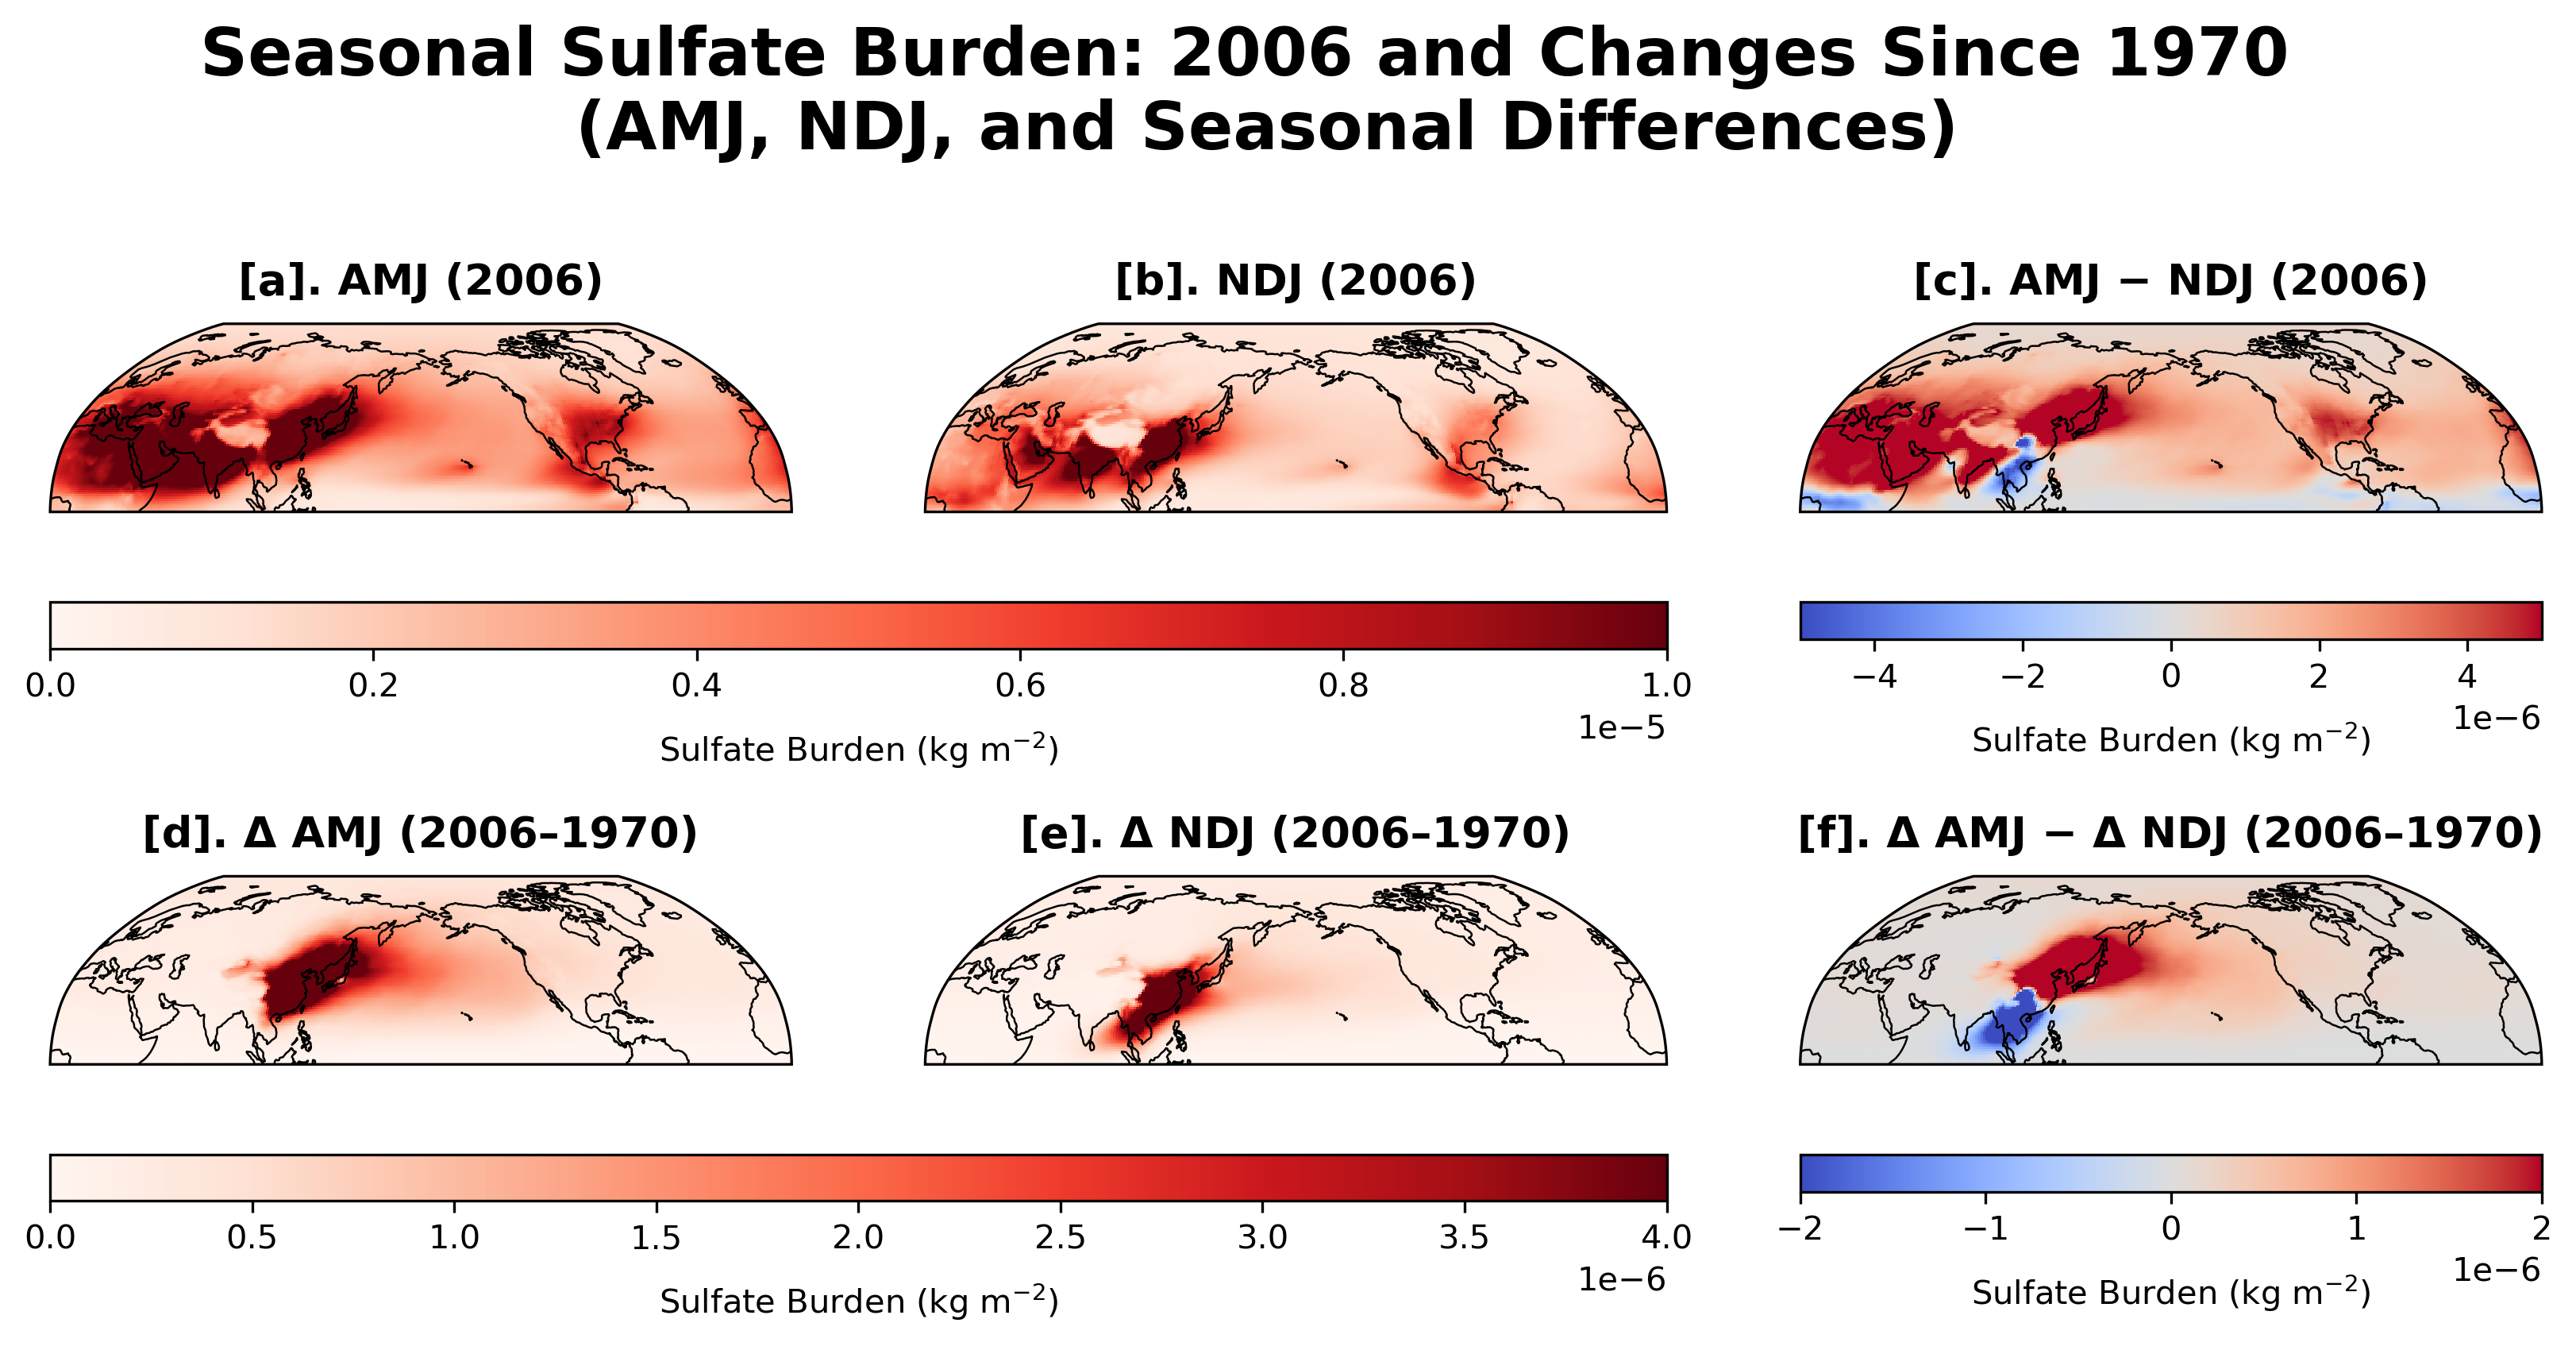

In [5]:
lon = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/dimension_files/model_dims/lon.nc')
lat = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/dimension_files/model_dims/lat.nc')

fig, axs = plt.subplots(2, 3, figsize=(13.5, 5.75), subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}, dpi=300)

axs = axs.flatten()

# -----------------------------
# Colorbar limits
# -----------------------------

vmin1, vmax1 = 0, 10e-6
vmin2, vmax2 = -5e-6, 5e-6
vmin3, vmax3 = 0, 4e-6
vmin4, vmax4 = -2e-6, 2e-6

# -----------------------------
# Plot panels
# -----------------------------

m1 = axs[0].pcolormesh(lon, lat, Burden_SO4_2006_AMJ, transform=ccrs.PlateCarree(), vmin=vmin1, vmax=vmax1, cmap='Reds')

m2 = axs[1].pcolormesh(lon, lat, Burden_SO4_2006_NDJ, transform=ccrs.PlateCarree(), vmin=vmin1, vmax=vmax1, cmap='Reds')

m3 = axs[2].pcolormesh(lon, lat, (Burden_SO4_2006_AMJ-Burden_SO4_2006_NDJ), transform=ccrs.PlateCarree(), vmin=vmin2, vmax=vmax2, cmap='coolwarm')

m4 = axs[3].pcolormesh(lon, lat, Burden_SO4_2006_AMJ-Burden_SO4_1970_AMJ, transform=ccrs.PlateCarree(), vmin=vmin3, vmax=vmax3, cmap='Reds')

m5 = axs[4].pcolormesh(lon, lat, Burden_SO4_2006_NDJ-Burden_SO4_1970_NDJ, transform=ccrs.PlateCarree(), vmin=vmin3, vmax=vmax3, cmap='Reds')

m6 = axs[5].pcolormesh(lon, lat, (Burden_SO4_2006_AMJ-Burden_SO4_1970_AMJ) -  (Burden_SO4_2006_NDJ-Burden_SO4_1970_NDJ), transform=ccrs.PlateCarree(), vmin=vmin4, vmax=vmax4, cmap='coolwarm')

# -----------------------------
# Map formatting
# -----------------------------

for ax in axs:
    ax.coastlines(linewidth=0.6)
    ax.set_extent([0, 360, 0, 90], crs=ccrs.PlateCarree())

titles = [

    "[a]. AMJ (2006)",

    "[b]. NDJ (2006)",

    "[c]. AMJ − NDJ (2006)",

    "[d]. Δ AMJ (2006–1970)",

    "[e]. Δ NDJ (2006–1970)",

    "[f]. Δ AMJ − Δ NDJ (2006–1970)",

]

for ax, title in zip(axs, titles):
    ax.set_title(title, fontsize=13, y=1.05, weight='bold')

plt.subplots_adjust(hspace=0.1, wspace=0.18, top=0.88)

# -----------------------------
# Colorbars
# -----------------------------

cbar1 = fig.colorbar(m1, aspect=35, pad=0.18, ax=[axs[0], axs[1]], orientation='horizontal')
cbar1.set_label(r'Sulfate Burden (kg m$^{-2}$)', labelpad=8)

cbar2 = fig.colorbar(m3, pad=0.18, ax=[axs[2]], orientation='horizontal')
cbar2.set_label(r'Sulfate Burden (kg m$^{-2}$)', labelpad=8)

cbar3 = fig.colorbar(m4, aspect=35, pad=0.18, ax=[axs[3], axs[4]], orientation='horizontal')
cbar3.set_label(r'Sulfate Burden (kg m$^{-2}$)', labelpad=8)

cbar4 = fig.colorbar(m6, pad=0.18, ax=[axs[5]], orientation='horizontal')
cbar4.set_label(r'Sulfate Burden (kg m$^{-2}$)', labelpad=8)

fig.suptitle('Seasonal Sulfate Burden: 2006 and Changes Since 1970 \n (AMJ, NDJ, and Seasonal Differences)', ha='center', va='center', fontsize=20, weight='bold', y=0.94)

# plt.savefig('/glade/u/home/jzweifel/jupyter_workspaces/Masters_paper_analysis/notebooks/saved_figures_pngs/Figure_06.png')

plt.show()